# Dataset Visualization

Files already downloaded and verified


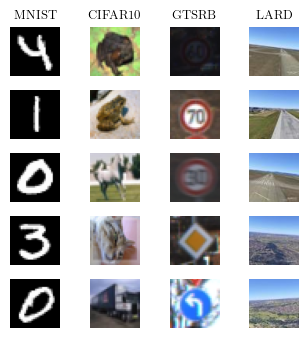

In [13]:
import random

import matplotlib.pyplot as plt
import torch

from vnn.datasets import MNIST, CIFAR10, MetaRoom, GTSRB, LARD
from vnn.visualization import setup_latex, get_figure_size, TEXTWIDTH_PT

setup_latex()

# random.seed(14)
random.seed(1)

mnist = MNIST()
cifar = CIFAR10()
metaroom = MetaRoom()
gtsrb = GTSRB()
lard = LARD(split="train", size=64)


datasets = [mnist, cifar, gtsrb, lard]
num_images = 5

fig_size = get_figure_size(TEXTWIDTH_PT, fraction=1)
# fig, axs = plt.subplots(num_images, 5, figsize=(15, 2 * num_images))
fig, axs = plt.subplots(num_images, len(datasets), figsize=fig_size)

for i in range(num_images):
    for j, dataset in enumerate(datasets):
        random_index = random.randint(0, len(dataset) - 1)
        img, _ = dataset[random_index]

        if dataset is cifar:
            mean = [0.485, 0.456, 0.406]
            std = [0.225, 0.225, 0.225]
            img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(
                3, 1, 1
            )

        row, col = i, j
        axs[row, col].imshow(img.clamp(0, 1).permute(1, 2, 0), cmap="gray")
        axs[row, col].axis("off")

        if i == 0:  # Add titles only for the first row
            dataset_name = type(dataset).__name__
            axs[row, col].set_title(dataset_name)

plt.tight_layout()
plt.savefig("datasets.pdf")
plt.show()

In [2]:
def plot_dataset(dataset, num_images=100, is_random=False):
    grid_size = int(num_images**0.5)
    fig, axs = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    if is_random:
        indices = random.sample(range(len(dataset)), num_images)
    else:
        indices = range(num_images)

    for idx in range(num_images):
        img, _ = dataset[indices[idx]]
        row, col = divmod(idx, grid_size)
        axs[row, col].imshow(img.clamp(0, 1).permute(1, 2, 0), cmap="gray")
        axs[row, col].axis("off")

    plt.tight_layout()
    plt.show()

## MNIST

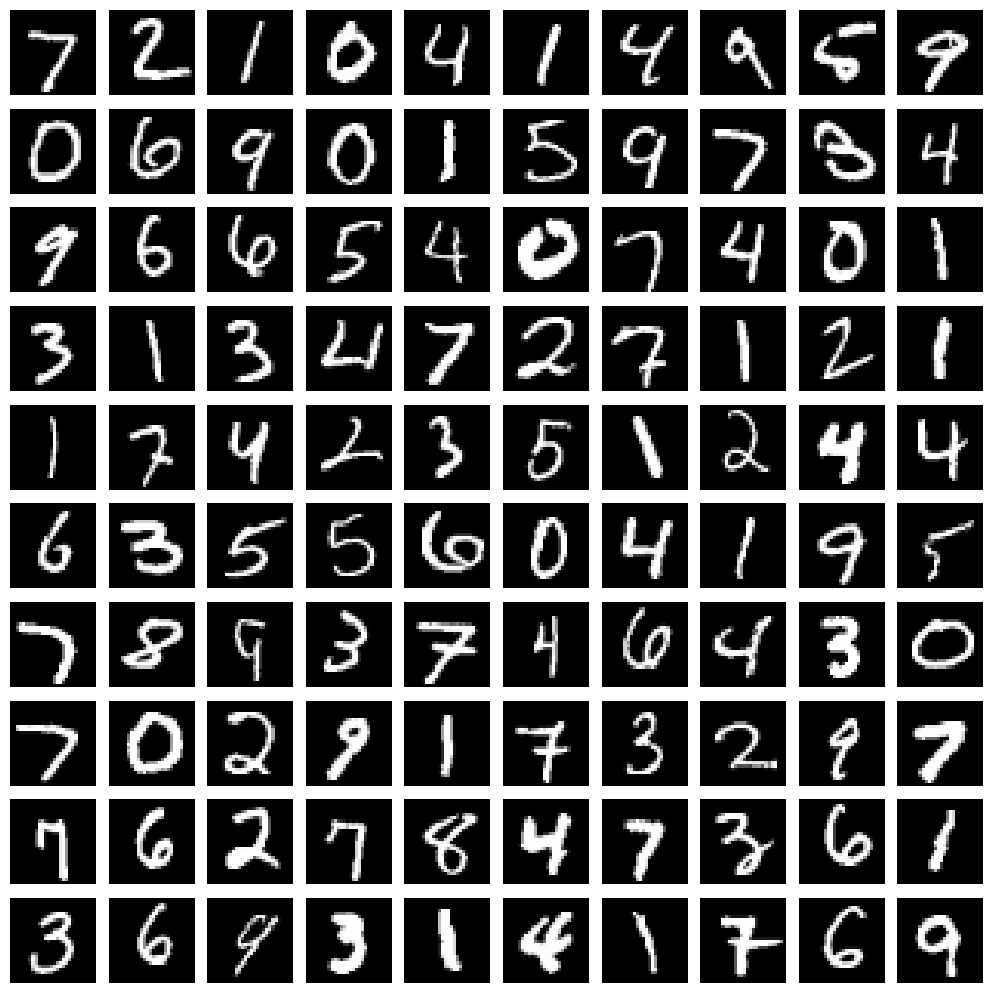

In [3]:
num_images = 100
plot_dataset(mnist, num_images=num_images)

## CIFAR-10

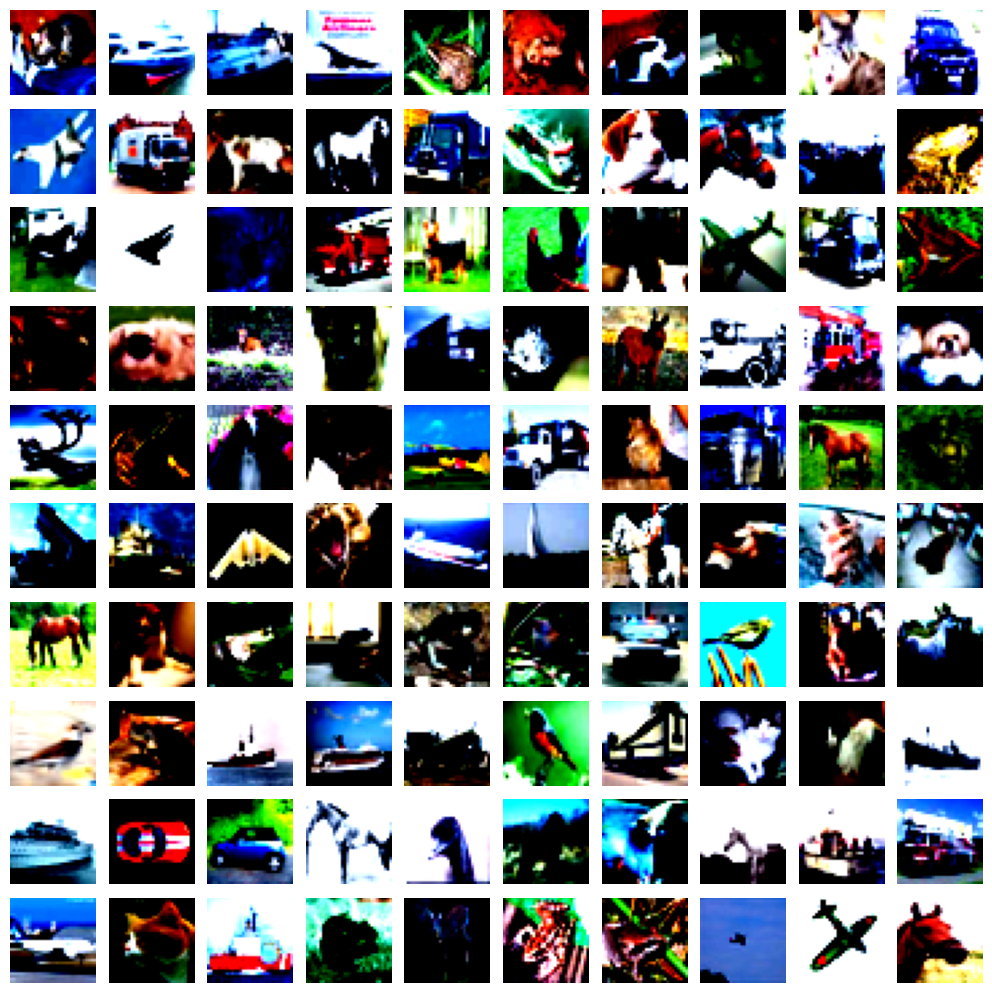

In [4]:
plot_dataset(cifar, num_images=num_images)

## GTSRB: German Traffic Sign Recognition Benchmark

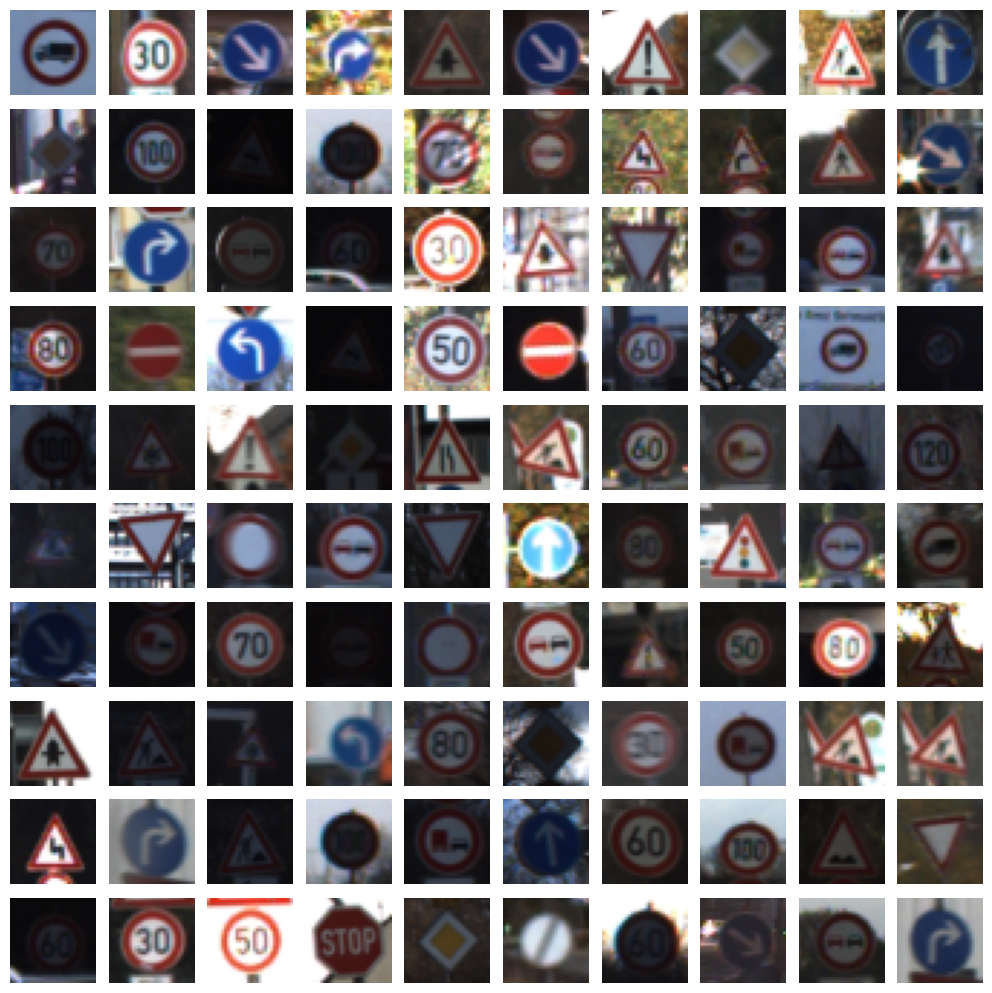

In [5]:
plot_dataset(gtsrb, num_images=num_images)

## MetaRoom: Indoor object recognition

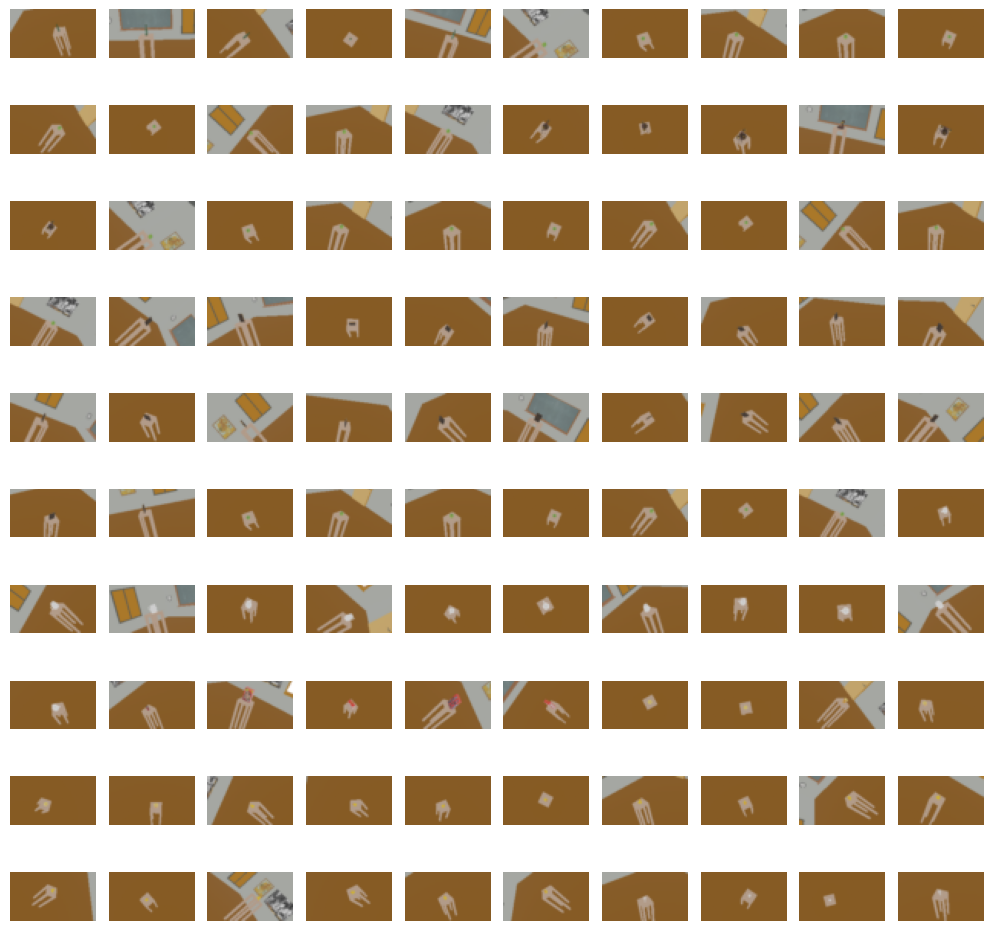

In [6]:
plot_dataset(metaroom, num_images=num_images)

## LARD: Landing Approach Runway Detection

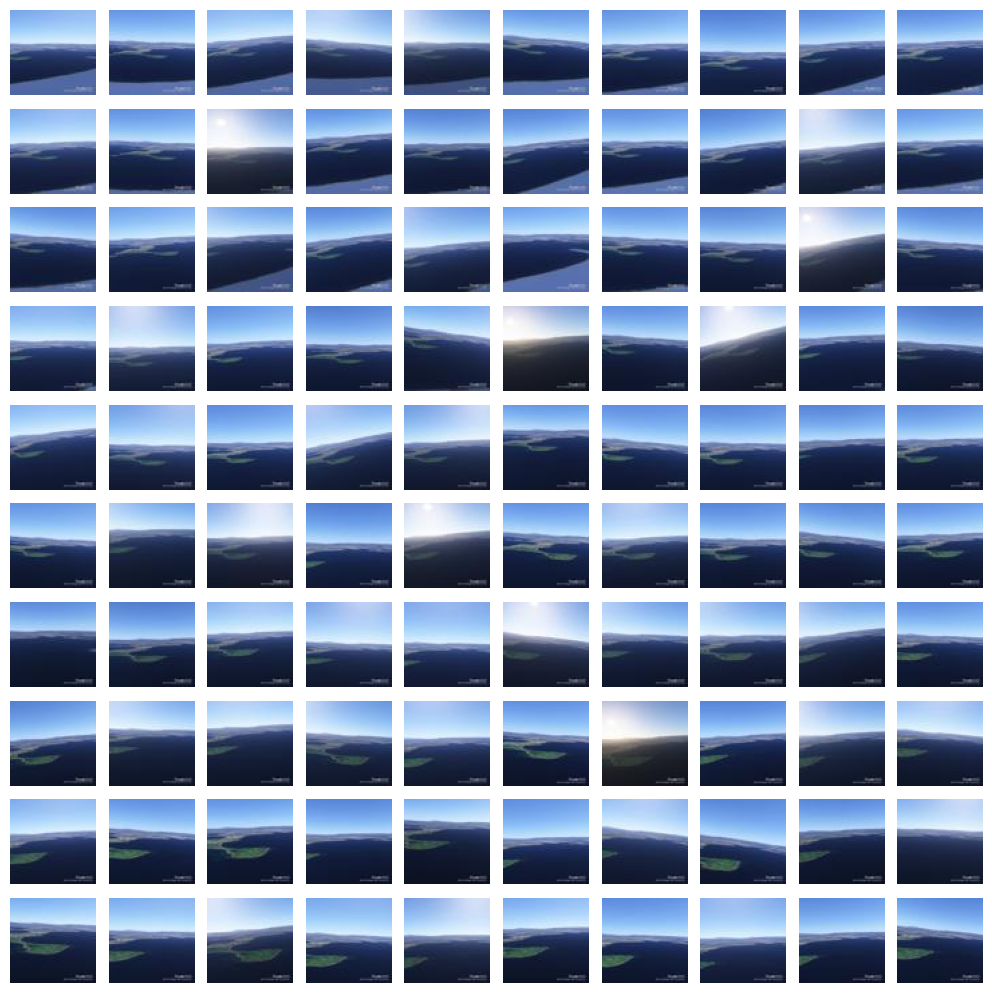

In [7]:
plot_dataset(lard, num_images=num_images)